Best Position: [-9.06516791e-07 -8.41132651e-08]
Best Fitness: 8.288477331876316e-13


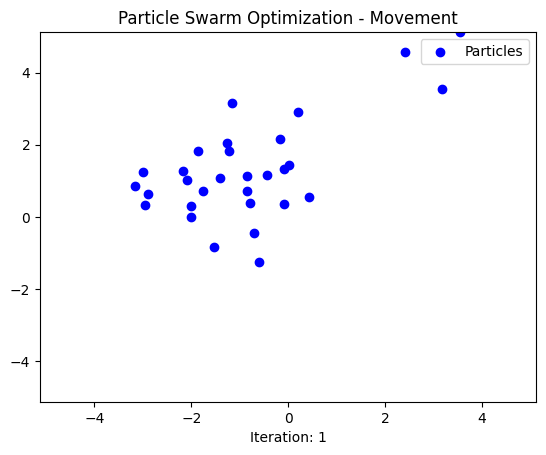

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Particle definition
class Particle:
    def __init__(self, bounds, num_dimensions):
        self.position = np.random.uniform(bounds[0], bounds[1], num_dimensions)
        self.velocity = np.random.uniform(-1, 1, num_dimensions)
        self.best_position = self.position.copy()
        self.best_fitness = float('inf')

# PSO algorithm
class PSO:
    def __init__(self, objective_func, num_particles, num_dimensions, bounds, max_iterations, w=0.5, c1=1.0, c2=2.0):
        self.objective_func = objective_func
        self.num_particles = num_particles
        self.num_dimensions = num_dimensions
        self.bounds = bounds
        self.max_iterations = max_iterations
        self.w = w
        self.c1 = c1
        self.c2 = c2
        self.particles = [Particle(bounds, num_dimensions) for _ in range(num_particles)]
        self.global_best_position = np.zeros(num_dimensions)
        self.global_best_fitness = float('inf')
        self.history = []

    def optimize(self):
        for iteration in range(self.max_iterations):
            positions = []
            for particle in self.particles:
                fitness = self.objective_func(particle.position)
                if fitness < particle.best_fitness:
                    particle.best_fitness = fitness
                    particle.best_position = particle.position.copy()
                if fitness < self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best_position = particle.position.copy()

            for particle in self.particles:
                r1 = np.random.rand(self.num_dimensions)
                r2 = np.random.rand(self.num_dimensions)
                cognitive = self.c1 * r1 * (particle.best_position - particle.position)
                social = self.c2 * r2 * (self.global_best_position - particle.position)
                particle.velocity = self.w * particle.velocity + cognitive + social
                particle.position += particle.velocity
                particle.position = np.clip(particle.position, self.bounds[0], self.bounds[1])
                positions.append(particle.position.copy())

            self.history.append(np.array(positions))
        return self.global_best_position, self.global_best_fitness

# Sphere function to minimize
def sphere_function(x):
    return np.sum(x**2)

# Run PSO
num_particles = 30
num_dimensions = 2
bounds = (-5.12, 5.12)
max_iterations = 50
pso = PSO(sphere_function, num_particles, num_dimensions, bounds, max_iterations)
best_position, best_fitness = pso.optimize()

print(f"Best Position: {best_position}")
print(f"Best Fitness: {best_fitness}")

# Animate particle movement
fig, ax = plt.subplots()
scat = ax.scatter([], [], c='blue', label='Particles')
ax.set_xlim(bounds[0], bounds[1])
ax.set_ylim(bounds[0], bounds[1])
ax.set_title("Particle Swarm Optimization - Movement")
ax.legend()

def update(frame):
    positions = pso.history[frame]
    scat.set_offsets(positions)
    ax.set_xlabel(f"Iteration: {frame + 1}")
    return scat,

ani = animation.FuncAnimation(fig, update, frames=max_iterations, interval=200, blit=True)

# Show animation
plt.show()
